In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Load the latest processed data from Exercise 5
input_path = "warehouse/final_sales.csv"

df = pd.read_csv(input_path)

print("Dataset loaded successfully!")
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

display(df.head())

Dataset loaded successfully!
Number of rows: 240
Number of columns: 9


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal


In [3]:
# Basic dataset information
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (240, 9)

Column Names:
['Transaction ID', 'Date', 'Product Category', 'Product Name', 'Units Sold', 'Unit Price', 'Total Revenue', 'Region', 'Payment Method']

Data Types:
Transaction ID        int64
Date                 object
Product Category     object
Product Name         object
Units Sold            int64
Unit Price          float64
Total Revenue       float64
Region               object
Payment Method       object
dtype: object


In [4]:
# Check missing values
print("Missing Values:")
display(df.isnull().sum())

# Check duplicate records
print("\nDuplicate Records:", df.duplicated().sum())

Missing Values:


Transaction ID      0
Date                0
Product Category    0
Product Name        0
Units Sold          0
Unit Price          0
Total Revenue       0
Region              0
Payment Method      0
dtype: int64


Duplicate Records: 0


In [5]:
# Make a copy so the original dataset is not modified
etl_df = df.copy()

# Convert Date to datetime
etl_df["Date"] = pd.to_datetime(etl_df["Date"], errors="coerce")

# Convert numeric columns to numeric types
numeric_columns = [
    "Transaction ID",
    "Units Sold",
    "Unit Price",
    "Total Revenue"
]

for col in numeric_columns:
    etl_df[col] = pd.to_numeric(etl_df[col], errors="coerce")

print("Data types after transformation:")
print(etl_df.dtypes)

Data types after transformation:
Transaction ID               int64
Date                datetime64[ns]
Product Category            object
Product Name                object
Units Sold                   int64
Unit Price                 float64
Total Revenue              float64
Region                      object
Payment Method              object
dtype: object


In [6]:
# Remove duplicate transactions
etl_df = etl_df.drop_duplicates(subset=["Transaction ID"])

# Remove records with essential missing values
essential_columns = [
    "Transaction ID",
    "Date",
    "Product Category",
    "Product Name",
    "Units Sold",
    "Unit Price",
    "Total Revenue",
    "Region",
    "Payment Method"
]

etl_df = etl_df.dropna(subset=essential_columns)

# Keep only valid sales values
etl_df = etl_df[
    (etl_df["Units Sold"] > 0) &
    (etl_df["Unit Price"] > 0) &
    (etl_df["Total Revenue"] > 0)
]

print("Records after ETL:", len(etl_df))

Records after ETL: 240


In [7]:
# Feature engineering
etl_df["Year"] = etl_df["Date"].dt.year
etl_df["Month"] = etl_df["Date"].dt.month
etl_df["Month Name"] = etl_df["Date"].dt.strftime("%B")

# Calculate revenue per unit
etl_df["Revenue Per Unit"] = (
    etl_df["Total Revenue"] / etl_df["Units Sold"]
)

print("Derived columns created successfully!")

display(etl_df.head())

Derived columns created successfully!


,Transaction ID,Date,Product Category,Product Name,Units Sold,Unit Price,Total Revenue,Region,Payment Method,Year,Month,Month Name,Revenue Per Unit
0,10001,2024-01-01,Electronics,iPhone 14 Pro,2,999.99,1999.98,North America,Credit Card,2024,1,January,999.99
1,10002,2024-01-02,Home Appliances,Dyson V11 Vacuum,1,499.99,499.99,Europe,PayPal,2024,1,January,499.99
2,10003,2024-01-03,Clothing,Levi's 501 Jeans,3,69.99,209.97,Asia,Debit Card,2024,1,January,69.99
3,10004,2024-01-04,Books,The Da Vinci Code,4,15.99,63.96,North America,Credit Card,2024,1,January,15.99
4,10005,2024-01-05,Beauty Products,Neutrogena Skincare Set,1,89.99,89.99,Europe,PayPal,2024,1,January,89.99


In [8]:
# ==============================
# DYNAMIC EDA SUMMARY
# ==============================

print("========== EDA SUMMARY ==========\n")

print("Total Records:", len(etl_df))
print("Total Revenue:", round(etl_df["Total Revenue"].sum(), 2))
print("Total Units Sold:", etl_df["Units Sold"].sum())
print("Average Revenue per Transaction:",
      round(etl_df["Total Revenue"].mean(), 2))

print("\nProduct Categories:")
display(
    etl_df["Product Category"]
    .value_counts()
    .rename_axis("Category")
    .reset_index(name="Number of Transactions")
)

print("\nRegions:")
display(
    etl_df["Region"]
    .value_counts()
    .rename_axis("Region")
    .reset_index(name="Number of Transactions")
)

========== EDA SUMMARY ==========

Total Records: 240
Total Revenue: 80567.85
Total Units Sold: 518
Average Revenue per Transaction: 335.7

Product Categories:


,Category,Number of Transactions
0,Electronics,40
1,Home Appliances,40
2,Clothing,40
3,Books,40
4,Beauty Products,40
5,Sports,40



Regions:


,Region,Number of Transactions
0,North America,80
1,Europe,80
2,Asia,80


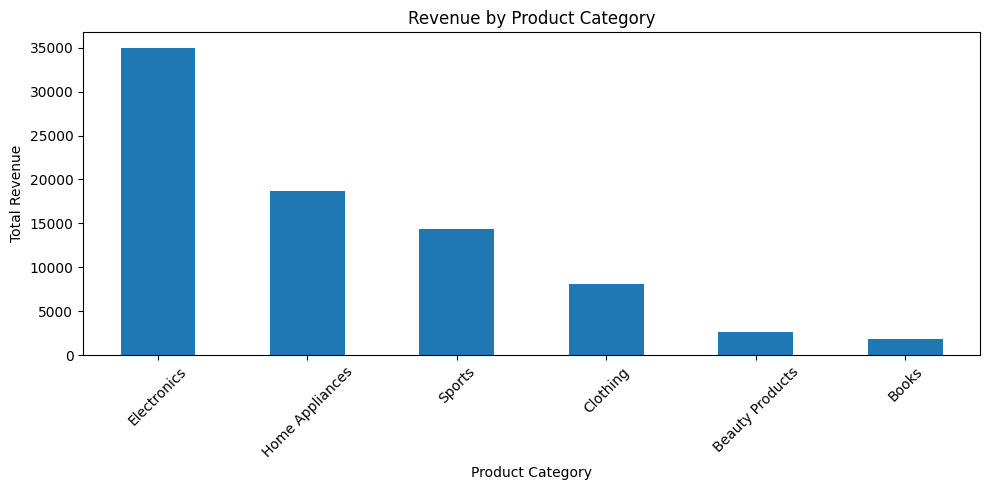

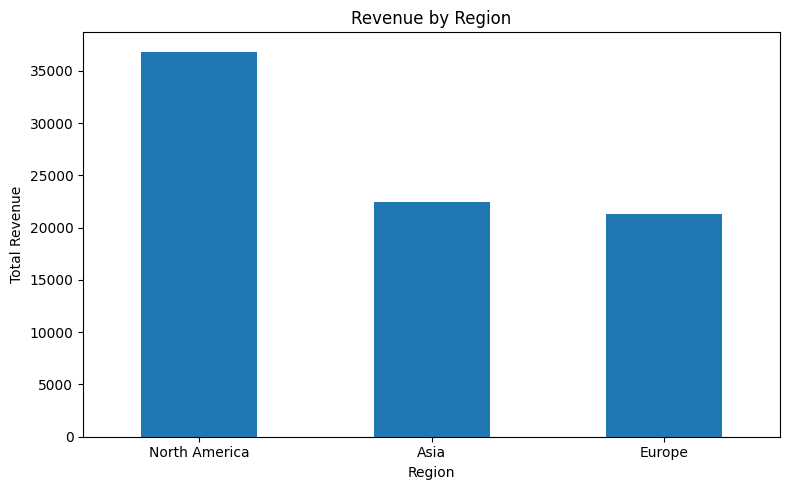

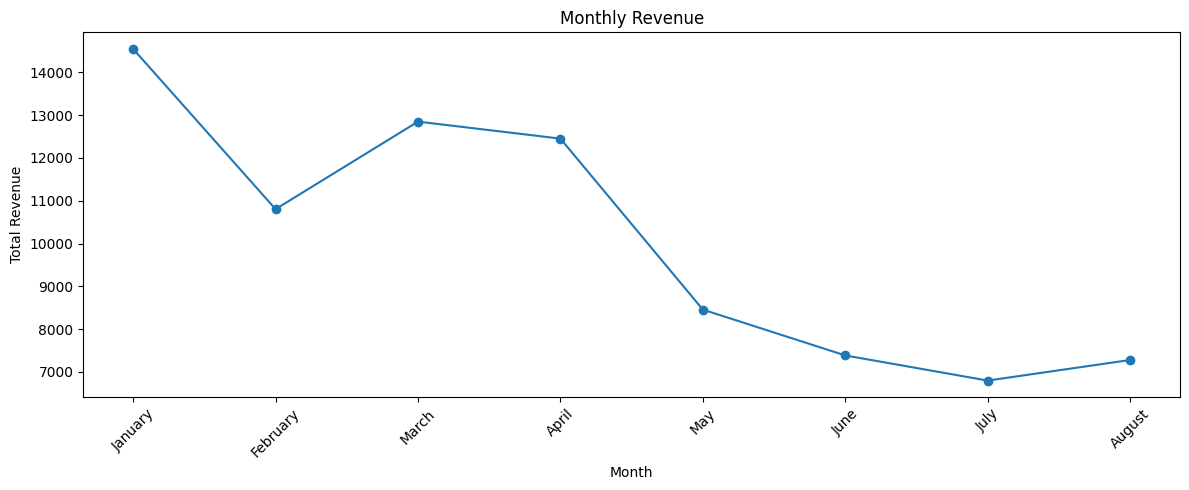

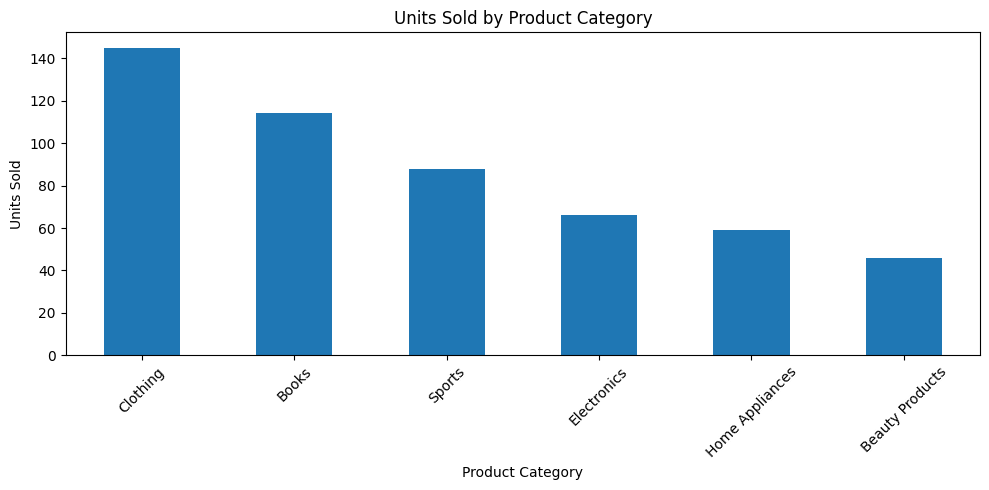

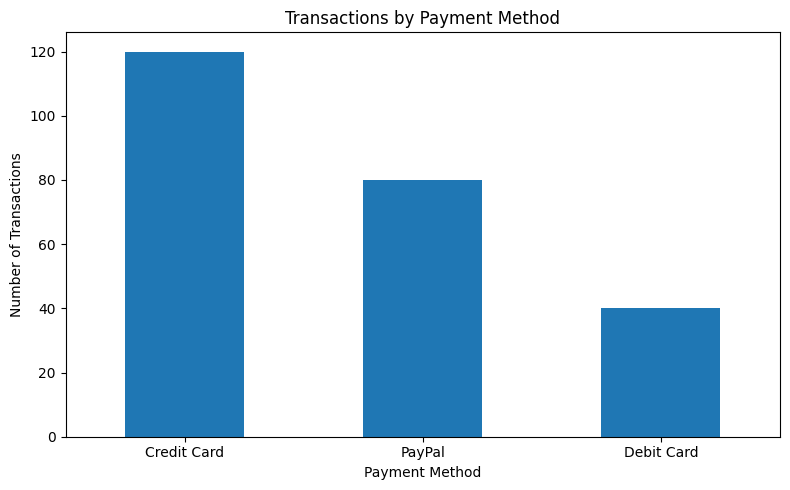

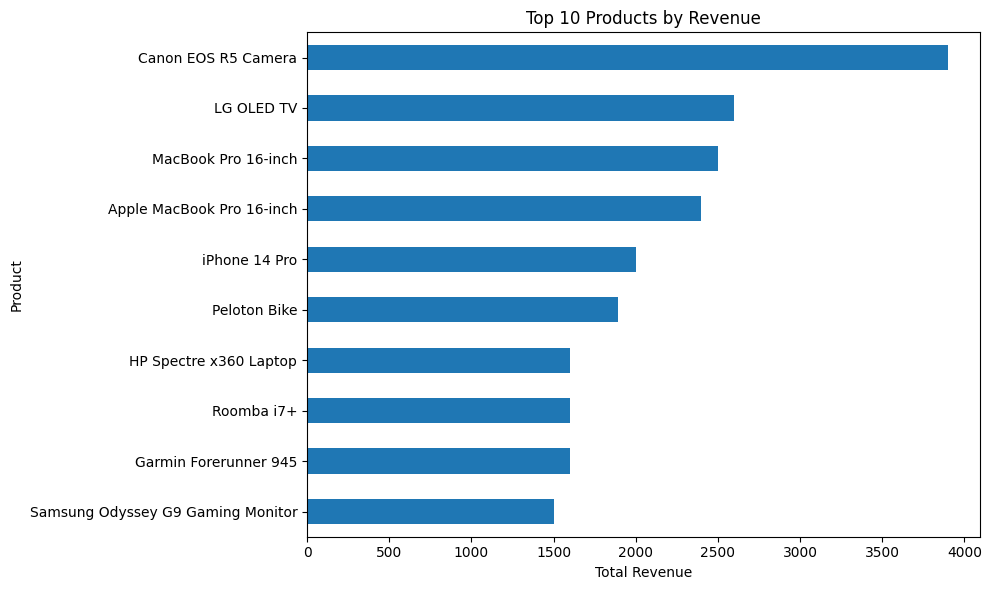

In [9]:
import matplotlib.pyplot as plt

# 1. Revenue by Product Category
category_revenue = (
    etl_df.groupby("Product Category")["Total Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
category_revenue.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 2. Revenue by Region
region_revenue = (
    etl_df.groupby("Region")["Total Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
region_revenue.plot(kind="bar")
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 3. Monthly Revenue
monthly_revenue = (
    etl_df.groupby(["Year", "Month", "Month Name"])["Total Revenue"]
    .sum()
    .reset_index()
    .sort_values(["Year", "Month"])
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_revenue["Month Name"], monthly_revenue["Total Revenue"], marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 4. Units Sold by Category
category_units = (
    etl_df.groupby("Product Category")["Units Sold"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
category_units.plot(kind="bar")
plt.title("Units Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# 5. Payment Method Distribution
payment_counts = etl_df["Payment Method"].value_counts()

plt.figure(figsize=(8, 5))
payment_counts.plot(kind="bar")
plt.title("Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 6. Top 10 Products by Revenue
top_products = (
    etl_df.groupby("Product Name")["Total Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()